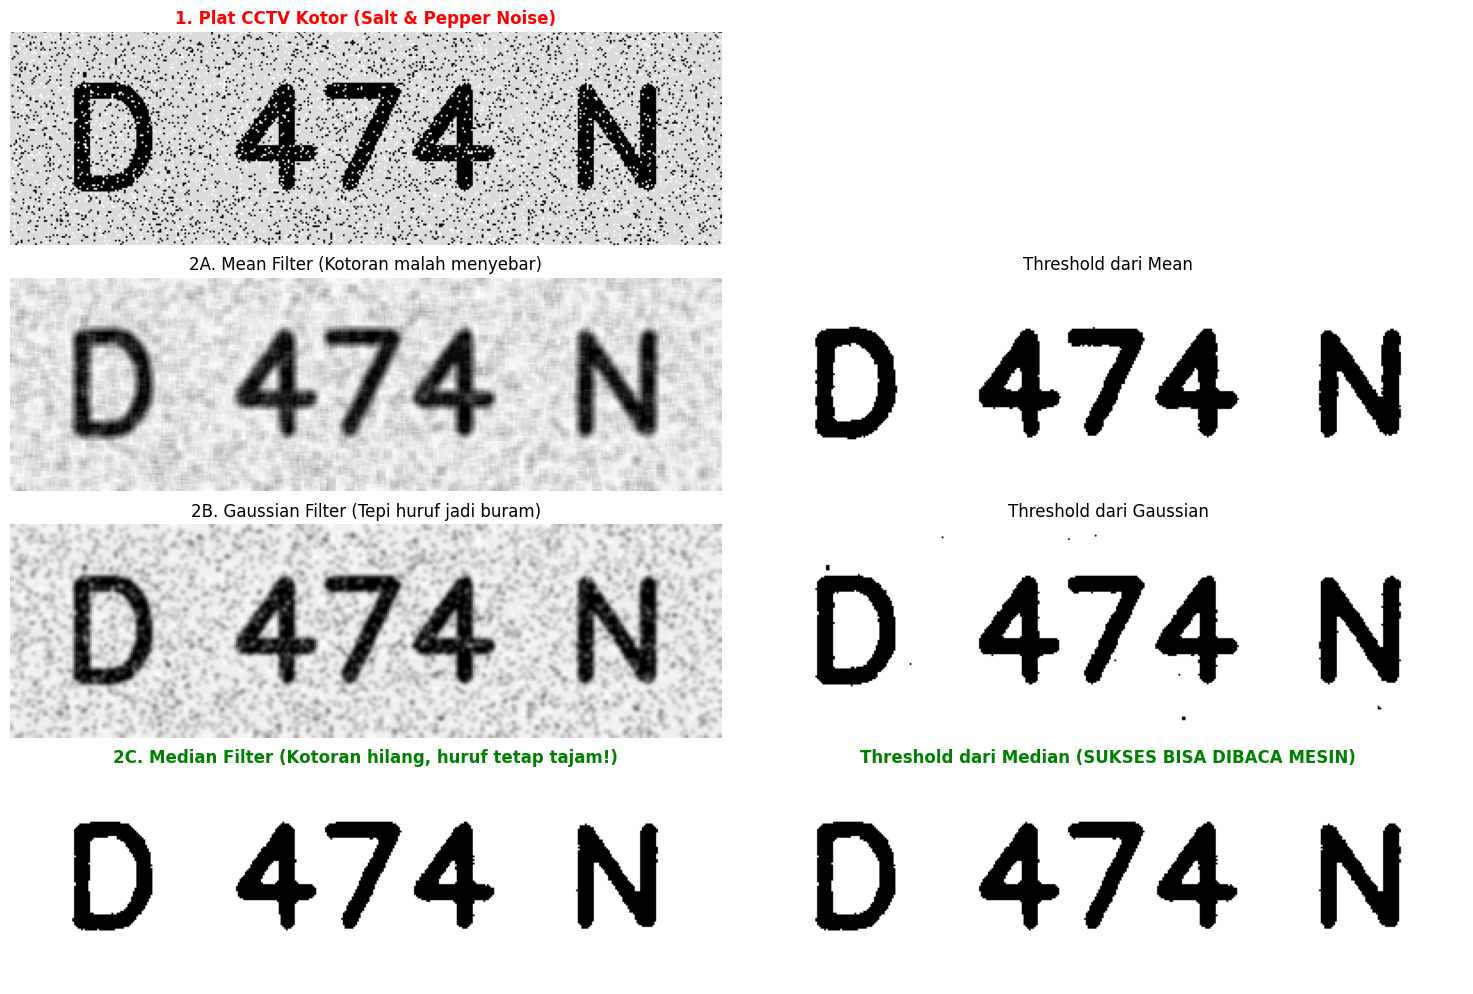

In [1]:
# ======================================================================
# PRAKTIKUM PERTEMUAN 4: OPERASI SPASIAL & NOISE REDUCTION
# Skenario: Plat nomor tertutup bintik kotoran / derau sensor (Salt & Pepper)
# Misi: Mencari filter kernel mana yang paling ahli membersihkan derau
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA: Membuat citra plat nomor yang sangat kotor
# ----------------------------------------------------------------------
# Membuat plat dasar
plat_bersih = np.ones((120, 400), dtype=np.uint8) * 220
cv2.putText(plat_bersih, "D 474 N", (30, 85), cv2.FONT_HERSHEY_SIMPLEX, 2.5, 0, 7)

# Mensimulasikan Salt & Pepper Noise (Bintik Hitam & Putih ekstrem)
# Ini sering terjadi pada CCTV murah malam hari atau transmisi data yang rusak
noise_matrix = np.zeros(plat_bersih.shape, np.uint8)
cv2.randu(noise_matrix, 0, 255)

plat_kotor = plat_bersih.copy()
plat_kotor[noise_matrix < 20] = 0     # Pepper (Bintik Hitam)
plat_kotor[noise_matrix > 235] = 255  # Salt (Bintik Putih)

# ----------------------------------------------------------------------
# 2. EKSPERIMEN FILTER SPASIAL MAHASISWA (Ukuran Kernel 5x5)
# ----------------------------------------------------------------------
ukuran_kernel = (5, 5)

# A. Mean Filter (Filter Rata-rata / Blur Biasa)
# Cara kerja: Menjumlahkan semua tetangga lalu dibagi rata.
filter_mean = cv2.blur(plat_kotor, ukuran_kernel)

# B. Gaussian Filter (Blur dengan bobot terpusat)
# Cara kerja: Tetangga yang dekat diberi bobot lebih besar dari yang jauh.
filter_gaussian = cv2.GaussianBlur(plat_kotor, ukuran_kernel, 0)

# C. Median Filter (Filter Non-Linear)
# Cara kerja: Mengurutkan nilai piksel tetangga, lalu mengambil nilai tengahnya.
filter_median = cv2.medianBlur(plat_kotor, 5)

# ----------------------------------------------------------------------
# 3. THRESHOLDING SEDERHANA UNTUK MELIHAT HASIL AKHIR
# ----------------------------------------------------------------------
# Mahasiswa membuktikan mana gambar yang paling siap dibaca komputer
_, biner_mean = cv2.threshold(filter_mean, 127, 255, cv2.THRESH_BINARY)
_, biner_gaussian = cv2.threshold(filter_gaussian, 127, 255, cv2.THRESH_BINARY)
_, biner_median = cv2.threshold(filter_median, 127, 255, cv2.THRESH_BINARY)

# ----------------------------------------------------------------------
# 4. VISUALISASI HASIL EKSPERIMEN
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 10))

plt.subplot(4, 2, 1)
plt.title("1. Plat CCTV Kotor (Salt & Pepper Noise)", color='red', fontweight='bold')
plt.imshow(plat_kotor, cmap='gray')
plt.axis('off')

# Hasil Rata-rata (Mean)
plt.subplot(4, 2, 3)
plt.title("2A. Mean Filter (Kotoran malah menyebar)")
plt.imshow(filter_mean, cmap='gray')
plt.axis('off')

plt.subplot(4, 2, 4)
plt.title("Threshold dari Mean")
plt.imshow(biner_mean, cmap='gray')
plt.axis('off')

# Hasil Gaussian
plt.subplot(4, 2, 5)
plt.title("2B. Gaussian Filter (Tepi huruf jadi buram)")
plt.imshow(filter_gaussian, cmap='gray')
plt.axis('off')

plt.subplot(4, 2, 6)
plt.title("Threshold dari Gaussian")
plt.imshow(biner_gaussian, cmap='gray')
plt.axis('off')

# Hasil Median
plt.subplot(4, 2, 7)
plt.title("2C. Median Filter (Kotoran hilang, huruf tetap tajam!)", color='green', fontweight='bold')
plt.imshow(filter_median, cmap='gray')
plt.axis('off')

plt.subplot(4, 2, 8)
plt.title("Threshold dari Median (SUKSES BISA DIBACA MESIN)", color='green', fontweight='bold')
plt.imshow(biner_median, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

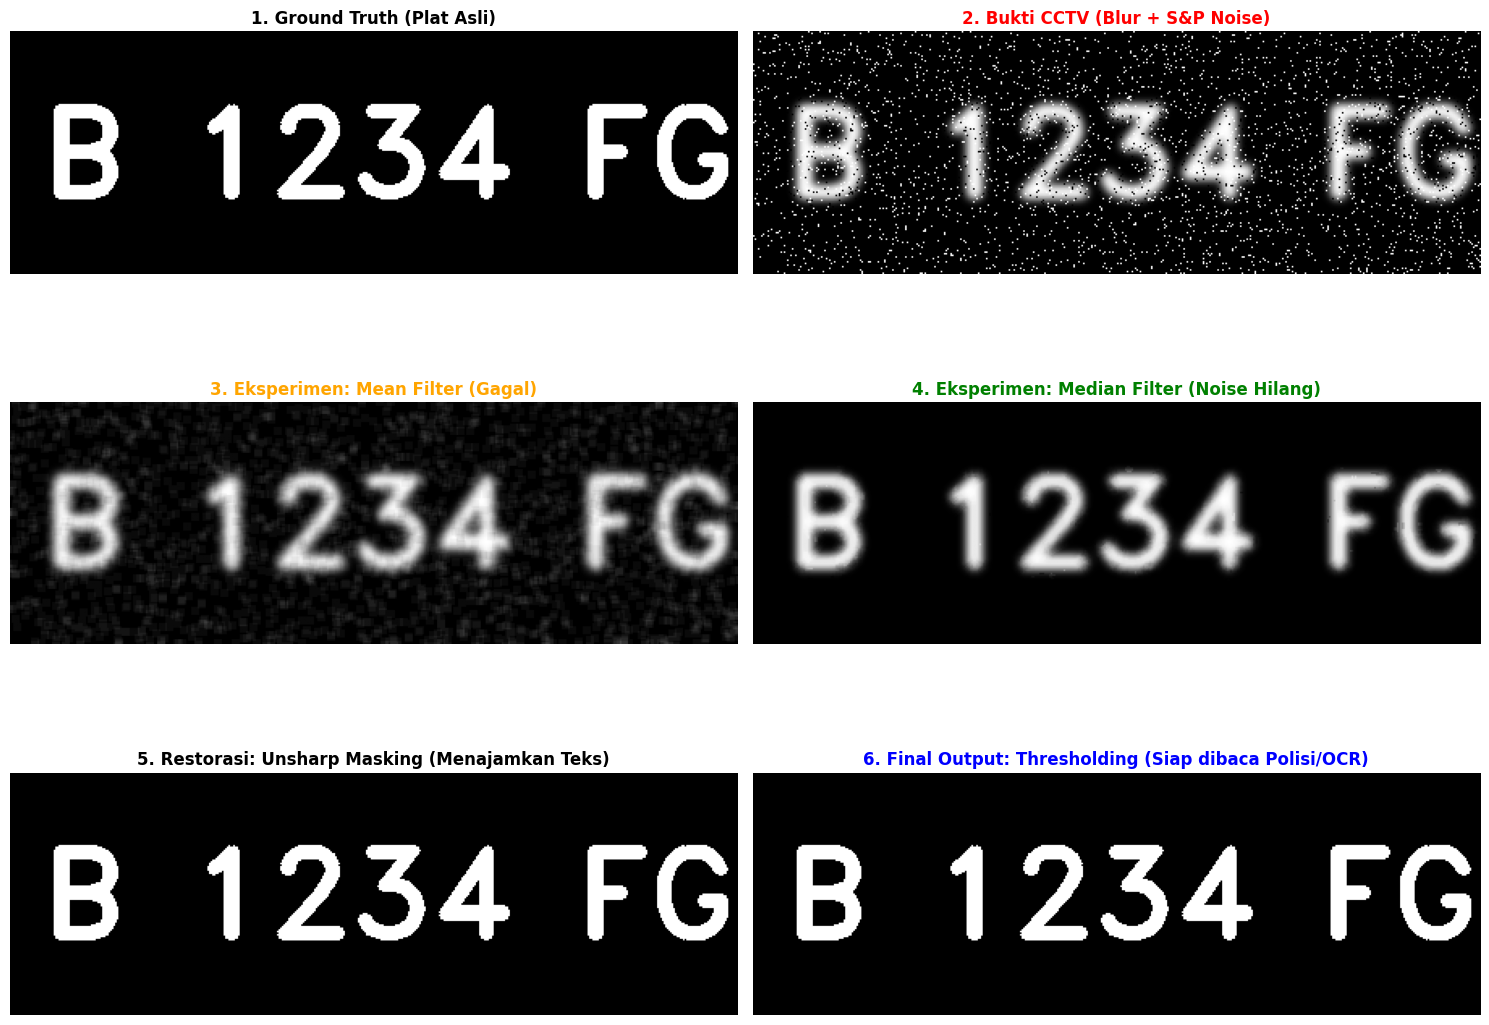

In [20]:
# ======================================================================
# TUGAS LAB 1: Lengkapi kode berikut
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. MEMBUAT DATASET SIMULASI (Ground Truth)
# Membuat citra plat nomor "B 1234 FGH"
# ----------------------------------------------------------------------
img_asli = np.zeros((150, 450), dtype=np.uint8)
cv2.putText(img_asli, "B 1234 FGH", (20, 100), cv2.FONT_HERSHEY_DUPLEX, 2.5, 255, 5)

# ----------------------------------------------------------------------
# 2. MERUSAK CITRA (Menambahkan Blur & Salt and Pepper Noise)
# ----------------------------------------------------------------------
# A. Tambahkan Blur (Kamera out-of-focus)
img_rusak = cv2.GaussianBlur(img_asli, (15, 15), 0)

# B. Tambahkan Salt & Pepper Noise (Bintik ekstrem)
prob_noise = 0.08 # 8% piksel rusak
rnd = np.random.rand(img_rusak.shape[0], img_rusak.shape[1])
img_rusak[rnd < prob_noise/2] = 0        # Pepper (Hitam)
img_rusak[rnd > 1 - prob_noise/2] = 255  # Salt (Putih)

# ----------------------------------------------------------------------
# 3. EKSPERIMEN 1: PENDEKATAN LINEAR (MEAN FILTER)
# ----------------------------------------------------------------------
# Menggunakan rata-rata 5x5
# TULISKAN CODE ANDA DISINI
img_mean = cv2.blur(img_rusak, (5,5))

# ----------------------------------------------------------------------
# 4. EKSPERIMEN 2: PENDEKATAN NON-LINEAR (MEDIAN FILTER)
# ----------------------------------------------------------------------
# Menggunakan nilai tengah 5x5
# TULISKAN CODE ANDA DISINI
img_median = cv2.medianBlur(img_rusak, 5)

# ----------------------------------------------------------------------
# 5. TAHAP LANJUTAN: PENAJAMAN KEMBALI (UNSHARP MASKING)
# Karena gambar dasarnya memang blur, kita tajamkan hasil dari Median Filter
# Rumus: Citra Tajam = Citra Asli + k * (Citra Asli - Citra Blur)
# ----------------------------------------------------------------------
# Kita gunakan fungsi addWeighted bawaan OpenCV untuk efisiensi
# TULISKAN CODE ANDA DISINI
mask = cv2.subtract(img_asli, img_median)
k = 1.5
img_tajam = cv2.addWeighted(img_asli, 1.0, mask, k, 0)

# ----------------------------------------------------------------------
# 6. TAHAP AKHIR: THRESHOLDING (Binarisasi untuk OCR)
# ----------------------------------------------------------------------
_, img_final = cv2.threshold(img_tajam, 127, 255, cv2.THRESH_BINARY)

# ----------------------------------------------------------------------
# VISUALISASI HASIL KOMPARASI
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.title("1. Ground Truth (Plat Asli)", fontweight='bold')
plt.imshow(img_asli, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.title("2. Bukti CCTV (Blur + S&P Noise)", fontweight='bold', color='red')
plt.imshow(img_rusak, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.title("3. Eksperimen: Mean Filter (Gagal)", fontweight='bold', color='orange')
plt.imshow(img_mean, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.title("4. Eksperimen: Median Filter (Noise Hilang)", fontweight='bold', color='green')
plt.imshow(img_median, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.title("5. Restorasi: Unsharp Masking (Menajamkan Teks)", fontweight='bold')
plt.imshow(img_tajam, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.title("6. Final Output: Thresholding (Siap dibaca Polisi/OCR)", fontweight='bold', color='blue')
plt.imshow(img_final, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# ======================================================================
# INSTALL ENGINE OCR (Jalankan cell ini satu kali saja)
# ======================================================================
!apt-get update
!apt install tesseract-ocr
!pip install pytesseract

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,620 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,954 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,955 kB]
Get:14 http://security.ubuntu

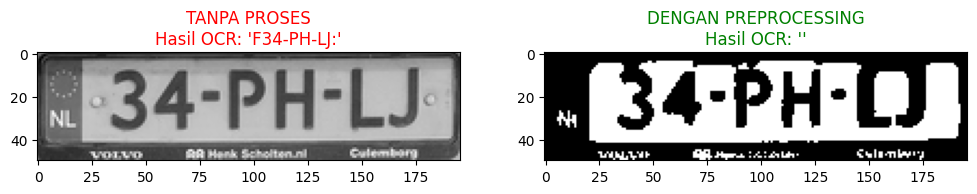

In [ ]:
# ======================================================================
# DATA ASLI: menggunakan Plat nomor asli dan OCR
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import pytesseract
import re

# 1. DOWNLOAD GAMBAR REAL-LIFE (Kasus bayangan/low contrast)
url = "https://raw.githubusercontent.com/openalpr/train-detector/1bd54b452c5fad1d7b5717a339664c85fefc4481/eu/eu-2.png"

try:
    req = urllib.request.urlopen(url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img_gray = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    plat_raw = img_gray
except:
    # Fallback jika link bermasalah: Buat simulasi gradien cahaya ekstrem
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300): plat_raw[:, i] = i * 0.5 # Gradien gelap ke terang
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)

# 2. JALUR TANPA PREPROCESSING (Langsung OCR)
config_ocr = r'--oem 3 --psm 7'
hasil_raw = pytesseract.image_to_string(plat_raw, config=config_ocr).strip()

# 3. JALUR DENGAN PREPROCESSING (The "Hero" Path)
# A. Bilateral Filter untuk buang noise tanpa merusak tepi huruf
filtered = cv2.bilateralFilter(plat_raw, 11, 75, 75)

# B. Top-Hat untuk meratakan pencahayaan (membuang gradien bayangan)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat = cv2.morphologyEx(filtered, cv2.MORPH_TOPHAT, kernel)

# C. Otsu Thresholding untuk mendapatkan biner bersih
_, biner = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# D. OCR pada hasil proses
hasil_processed = pytesseract.image_to_string(biner, config=config_ocr).strip()

# 4. VISUALISASI PERBANDINGAN
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"TANPA PROSES\nHasil OCR: '{hasil_raw}'", color='red')
plt.imshow(plat_raw, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"DENGAN PREPROCESSING\nHasil OCR: '{hasil_processed}'", color='green')
plt.imshow(biner, cmap='gray')
plt.show()

In [12]:
# Menghubungkan Drive ke colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


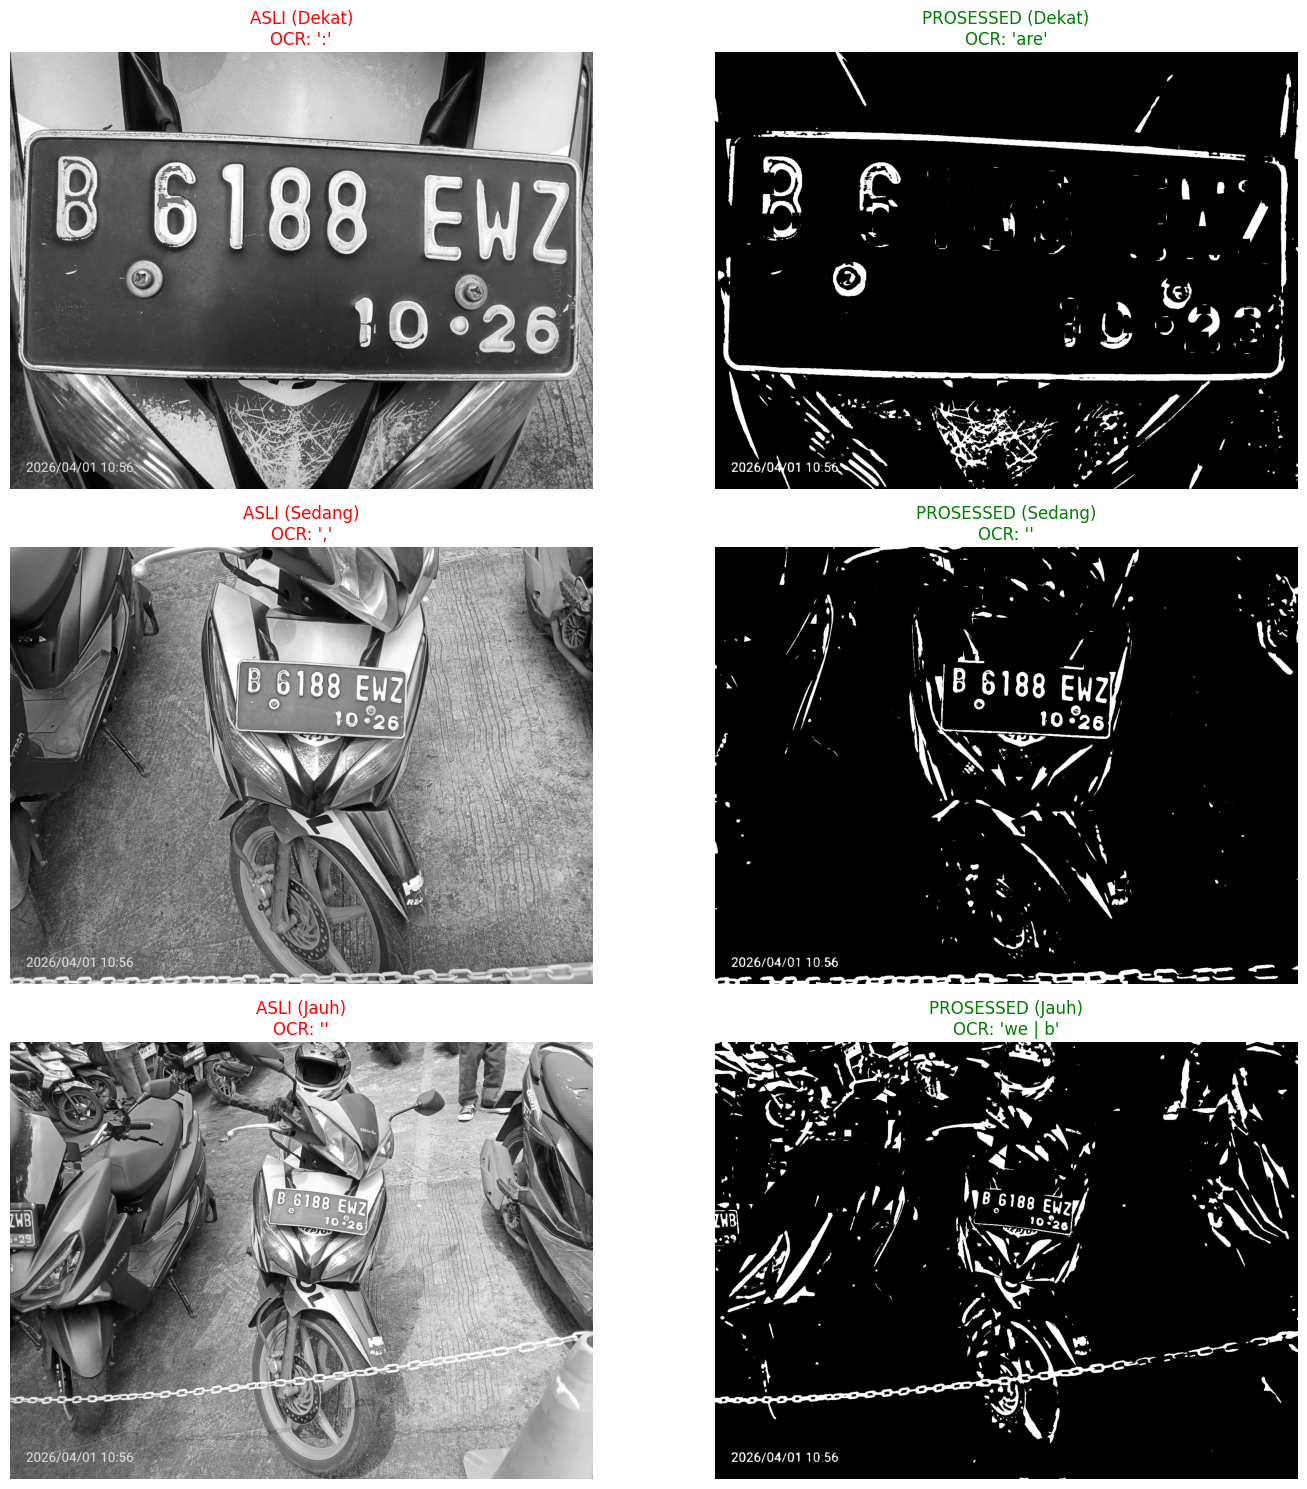

In [19]:
# ======================================================================
# TUGAS LAB 2: PLAT KENDARAAN PRIBADI
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

# 1. Foto plat nomor kendaraan anda dengan 3 jarak berbeda
paths = {
    "Dekat":  "/content/drive/MyDrive/Pengolahan_Citra/dekat.jpeg",
    "Sedang": "/content/drive/MyDrive/Pengolahan_Citra/sedang.jpeg",
    "Jauh":   "/content/drive/MyDrive/Pengolahan_Citra/jauh.jpeg"
}

# Load gambar ubah ke Grayscale
imgs = {k: cv2.imread(v, cv2.IMREAD_GRAYSCALE) for k, v in paths.items()}

# 2. Lakukan proses pembacaan plat nomor (OCR) untuk ketiga foto tersebut
config_ocr = r'--oem 3 --psm 7'
hasil_awal = {k: pytesseract.image_to_string(v, config=config_ocr).strip() for k, v in imgs.items()}

# 3. Lakukan teknik praproses pada citra tersebut

def pengolahan_citra(img):
    # A. Bilateral Filter (Buang noise, jaga tepi)
    filtered = cv2.bilateralFilter(img, 11, 75, 75)

    # B. Top-Hat (Meratakan pencahayaan)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
    tophat = cv2.morphologyEx(filtered, cv2.MORPH_TOPHAT, kernel)

    # C. Otsu Thresholding (Binerisasi)
    # Tidak perlu cvtColor karena input sudah grayscale
    _, biner = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return biner

# Terapkan fungsi ke semua gambar
biner_results = {k: pengolahan_citra(v) for k, v in imgs.items()}

# --- 4. OCR HASIL PROSES ---
hasil_akhir = {k: pytesseract.image_to_string(v, config=config_ocr).strip() for k, v in biner_results.items()}

# 4. Bandingkan hasilnya
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
titles = list(paths.keys())

for i, title in enumerate(titles):
    # Gambar Asli OCR Tanpa Process (Grayscale)
    axes[i, 0].imshow(imgs[title], cmap='gray')
    axes[i, 0].set_title(f"ASLI ({title})\nOCR: '{hasil_awal[title]}'", color='red')
    axes[i, 0].axis('off')

    # Gambar Hasil OCR dengan Proses (Biner)
    axes[i, 1].imshow(biner_results[title], cmap='gray')
    axes[i, 1].set_title(f"PROSESSED ({title})\nOCR: '{hasil_akhir[title]}'", color='green')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# ======================================================================
# LAPORAN ANALISIS
# ======================================================================
# 1. Analisis Spasial
# Bandingkan hasil dari Median Filter dan Bilateral Filter pada TUGAS 1.
# Jelaskan secara matematis mengapa Bilateral Filter mampu mempertahankan sudut tajam pada angka '4',
# sedangkan Median Filter membuatnya tumpul!
# Jawaban <br>
Bilateral Filter mampu mempertahankan sudut tajam pada angka '4' karena menggunakan dua fungsi Gaussian secara simultan: satu untuk jarak spasial dan satu lagi untuk selisih intensitas warna (range kernel). Secara matematis, bobot piksel tetangga akan mendekati nol jika terdapat perbedaan kontras yang besar antara karakter angka dan latar belakang. Hal ini mencegah terjadinya pencampuran nilai piksel yang berbeda warna di area tepi, sehingga gradien tajam pada sudut tetap terjaga. Berbeda dengan Median Filter yang hanya bekerja berdasarkan urutan statistik dan sering kali mengeliminasi piksel sudut sebagai "minoritas", Bilateral Filter bersifat edge-aware yang hanya melakukan penghalusan pada area dengan intensitas serupa.

# 2. Paradoks Preprocessing (Bobot 25%)
# Pada Kasus Plat asli, preprocessing justru merusak hasil pembacaan Tesseract.
# Jelaskan hubungan antara teknik Thresholding ekstrem dengan hilangnya piksel anti-aliasing,
# dan mengapa model Tesseract (LSTM) modern lebih menyukai gambar asli (grayscale) pada kondisi cahaya ideal!
# Jawaban <br>
Binarisasi atau thresholding ekstrem sering kali merusak hasil OCR karena menghilangkan piksel anti-aliasing, yaitu gradien warna abu-abu halus di tepi huruf yang berfungsi menjaga kemulusan bentuk karakter. Secara matematis, pemaksaan piksel menjadi hitam atau putih murni menyebabkan tepi huruf menjadi bergerigi (aliasing) atau bahkan terputus, sehingga morfologi asli karakter menjadi cacat. Model Tesseract modern yang berbasis arsitektur LSTM (Long Short-Term Memory) lebih menyukai citra grayscale pada kondisi cahaya ideal karena model deep learning ini dilatih untuk mengenali fitur berdasarkan gradien dan tekstur yang kaya informasi. Dengan mempertahankan data mentah, LSTM dapat melakukan ekstraksi fitur yang lebih akurat dibandingkan pada citra biner yang informasinya sudah terbuang dan penuh dengan artefak digital.